In [1]:
import numpy as np
import networkx as nx
import numpy.typing as npt
from collections import Counter
from typing import Optional
from itertools import combinations

from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz

from qiskit_ibm_runtime import QiskitRuntimeService


from qopt_best_practices.sat_mapping import SATMapper

from qiskit_qaoa.utils.circuit_graph_utils import circuit_to_graph, graph_to_operator, circuit_construction
from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qubo_qaoa.utils.swap_strategy import ExtendedSwapStrategy
from qiskit_qaoa.utils.logging import get_logger

logger = get_logger(__name__)


def print_circuit_info(qc, circuit_name):
    logger.info(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0) + qc.count_ops().get("ecr", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')


filename: str = 'test_N2_W2'
N: int = 2
shots: int = 4000
p=1

data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

Q, hamiltonian, offset, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits


rows, cols = 1, 1
while 4 * (rows + cols + rows * cols) < num_qubits:
    if rows < cols:
        rows += 1
    else:
        cols += 1
print(f'Min size to support virtual qubits: {(rows, cols)}')
swap_strat = ExtendedSwapStrategy.from_heavy_hex(rows, cols)
coupling_map = swap_strat._coupling_map
coupling_map_edge = list(coupling_map)
physical_qubits = list(coupling_map.physical_qubits)

dual_coupling_map = nx.Graph()

for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))
edge_colouring = nx.greedy_color(dual_coupling_map, interchange=True)


qc = QAOAAnsatz(
    cost_operator=hamiltonian,
    reps = 1,
    flatten=True
)
graph = circuit_to_graph(qc, qc.parameters[1])



Min size to support virtual qubits: (1, 1)


In [2]:
for row, col in [(1,1), (1,2), (2,2), (3,2), (3,3), (4, 3), (4,4)]:
    print(len(nx.hexagonal_lattice_graph(row, col)), 2 * (row * col +row + col))
    print()

6 6

10 10

16 16

22 22

30 30

38 38

48 48



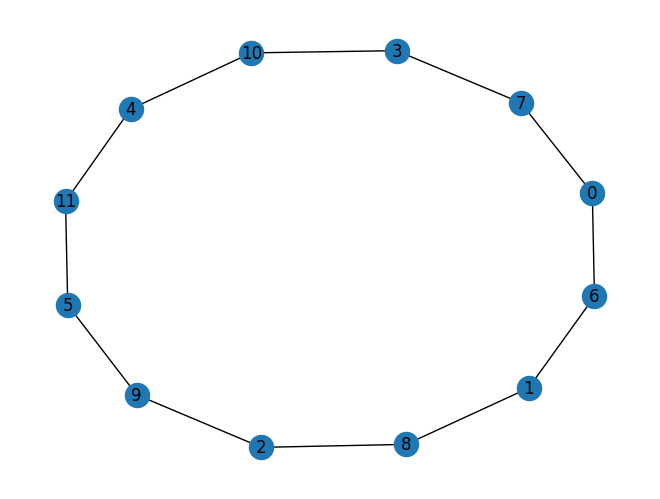

In [3]:
nx.draw(nx.Graph(list(swap_strat._coupling_map)), with_labels=True)

In [4]:
remapped_g, sat_map, min_sat_layers = SATMapper(timeout=30).remap_graph_with_sat(
    graph=graph, swap_strategy=swap_strat, max_layers = int(num_qubits + np.sqrt(num_qubits) + 61)
)
if remapped_g is None:
    raise Exception('Failed to find initial layout')

In [5]:
sat_map

{0: 10, 1: 4, 2: 8, 3: 1, 4: 7, 5: 6, 6: 3, 7: 0}

In [41]:
inv_sat_map = {v: k for k, v in sat_map.items()}

In [42]:
inv_sat_map

{10: 0, 4: 1, 8: 2, 1: 3, 7: 4, 6: 5, 3: 6, 0: 7}

In [6]:
min_sat_layers

7

In [7]:
remapped_g.edges(data=True)

EdgeDataView([(10, 10, {'weight': -9.75}), (10, 4, {'weight': 5.5}), (10, 8, {'weight': 5.0}), (10, 1, {'weight': 5.0}), (10, 7, {'weight': 0.5}), (10, 6, {'weight': 0.5}), (10, 3, {'weight': -1.25}), (4, 4, {'weight': -11.0}), (4, 8, {'weight': 5.0}), (4, 1, {'weight': 5.0}), (4, 7, {'weight': 0.5}), (4, 6, {'weight': 0.5}), (8, 8, {'weight': -11.0}), (8, 1, {'weight': 5.5}), (8, 3, {'weight': 0.5}), (8, 0, {'weight': 0.5}), (1, 1, {'weight': -9.75}), (1, 6, {'weight': -1.25}), (1, 3, {'weight': 0.5}), (1, 0, {'weight': 0.5}), (7, 7, {'weight': -11.0}), (7, 6, {'weight': 5.5}), (7, 3, {'weight': 5.0}), (7, 0, {'weight': 5.0}), (6, 6, {'weight': -9.75}), (6, 3, {'weight': 5.0}), (6, 0, {'weight': 5.0}), (3, 3, {'weight': -9.75}), (3, 0, {'weight': 5.5}), (0, 0, {'weight': -11.0})])

In [8]:
cost_op = graph_to_operator(remapped_g, swap_strat._num_vertices)
# cost_op = graph_to_operator(remapped_g)


In [9]:
singles = cost_op[cost_op.paulis.z.sum(axis=-1) == 1]
doubles = cost_op[cost_op.paulis.z.sum(axis=-1) == 2]

In [10]:
singles

SparsePauliOp(['IZIIIIIIIIII', 'IIIIIIIZIIII', 'IIIZIIIIIIII', 'IIIIIIIIIIZI', 'IIIIZIIIIIII', 'IIIIIZIIIIII', 'IIIIIIIIZIII', 'IIIIIIIIIIIZ'],
              coeffs=[ -9.75+0.j, -11.  +0.j, -11.  +0.j,  -9.75+0.j, -11.  +0.j,  -9.75+0.j,
  -9.75+0.j, -11.  +0.j])

In [11]:
clone = {}
for k, v in edge_colouring.items():
    clone[k] = v
    clone[k[::-1]] = v

In [12]:
service = QiskitRuntimeService(name='eu_test_instance')
backend = service.least_busy(min_num_qubits=num_qubits, operational=True, simulator=False) 

In [13]:
from qopt_best_practices.transpilation import qaoa_swap_strategy_pm

n = len(doubles[0].paulis[0])
doubles_circ = QAOAAnsatz(
    doubles,
    initial_state=QuantumCircuit(n),
    mixer_operator=QuantumCircuit(n)
)
config = {
    "num_layers": 1,
    "swap_strategy": swap_strat,
    "edge_coloring": clone,
    "construct_qaoa": False,
    "basis_gates": ["rz", "cx", "swap"]
}
properties = {}
def get_permutation(pass_, dag, time, property_set, count):
    properties["virtual_permutation_layout"] = property_set["virtual_permutation_layout"]
pm = qaoa_swap_strategy_pm(config)
tdoubles_circ = pm.run(doubles_circ, callback=get_permutation)


In [14]:
doubles_circ.decompose(reps=2).draw(fold=-1)

q_0: ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────────────────■────────────■───────────────────────────■─────────────■────────────
                                                                                                                                                                           │                         │ZZ(γ[0])    │                           │             │            
 q_1: ─────────────────────────────■───────────────────────────■─────────────■───────────────────────────────────────────────────────────────────────────■─────────────────┼───────────■─────────────■────────────┼───────────────────────────┼─────────────┼────────────
                                   │                           │             │                                                                           │                 │           │                          │                           │             │            
 q_2: ─────────────────────────────┼───────────────────────────┼─────────────┼───────────────────────────────────────────────────────────────────────────┼─────────────────┼───────────┼──────────────────────────┼───────────────────────────┼─────────────┼────────────
                                   │                           │             │                                                                           │                 │           │ZZ(γ[0])                  │                           │             │ZZ(11*γ[0]) 
 q_3: ─────────────────────────────┼───────────────────────────┼─────────────┼───────────────────────────────────■────────────────────────────■──────────┼─────────────────┼───────────■────────────■─────────────┼─────────────■─────────────┼─────────────■────────────
                                   │                           │ZZ(10*γ[0])  │                                   │                            │          │                 │                        │             │             │             │                          
 q_4: ─■───────────────────────────┼─────────────■─────────────■─────────────┼─────────────■─────────────────────┼─────────────────■──────────┼──────────┼─────────────────┼────────────────────────┼─────────────┼─────────────┼─────────────┼──────────────────────────
       │                           │             │                           │             │                     │                 │          │          │                 │                        │             │             │             │                          
 q_5: ─┼───────────────────────────┼─────────────┼───────────────────────────┼─────────────┼─────────────────────┼─────────────────┼──────────┼──────────┼─────────────────┼────────────────────────┼─────────────┼─────────────┼─────────────┼──────────────────────────
       │                           │             │                           │             │                     │                 │ZZ(γ[0])  │          │ZZ((-2.5)*γ[0])  │                        │             │             │ZZ(10*γ[0])  │ZZ(10*γ[0])               
 q_6: ─┼───────────────────────────┼─────────────┼───────────────────────────┼─────────────┼──────────■──────────┼─────────────────■──────────┼──────────■─────────────────┼──────────■─────────────┼─────────────┼─────────────■─────────────■──────────────────────────
       │                           │             │                           │             │ZZ(γ[0])  │          │                            │                            │          │ZZ(11*γ[0])  │ZZ(10*γ[0])  │ZZ(10*γ[0])                                           
 q_7: ─┼───────────────────────────┼─────────────┼──────────────■────────────┼─────────────■──────────┼──────────┼────────────────────────────┼────────────────────────────┼──────────■─────────────■─────────────■──────────────────────────────────────────────────────
       │   

In [15]:
tdoubles_circ.draw(fold=-1)

┌───┐┌─────────────┐                       ┌───┐                                                                                                                           ┌───┐┌─────────────┐                      ┌───┐                                                                                                                                       
  q_0 -> 0 ──■────────────────────────────────────────■───────────────────■───────────────────────────────────────────■─────────────X───────────────────────────┤ X ├┤ Rz(10*γ[0]) ├───────────────────────┤ X ├──────────────X────────────────────────■───────────────────────────────────■──────────────────────X────────────────────────┤ X ├┤ Rz(10*γ[0]) ├──────────────────────┤ X ├───────────────X───────X───────────────────────────────────────────────────────────────────────────────────────────────────────────────
             │                                        │                   │                                           │             │          ┌───┐┌──────────┐└─┬─┘└─────────────┘                  ┌───┐└─┬─┘              │                        │                                   │                      │                        └─┬─┘└─────────────┘                      └─┬─┘               │       │                          ┌───┐┌─────────────┐                                             ┌───┐               
  q_1 -> 1 ──┼─────────■──────────────────────────────┼─────────■─────────┼─────────■─────────────────────────────────┼────■────────┼──X───────┤ X ├┤ Rz(γ[0]) ├──┼───────────────────────────────────┤ X ├──┼─────────────X──┼────────────────────X───┼───────────────────────────────────┼──────────────────────┼──────────────────────X───┼────────────────────────────X────────────┼─────────────────┼───────┼───────────────X──────────┤ X ├┤ Rz(10*γ[0]) ├─────────────────────────────────────────────┤ X ├───────────────
             │         │                              │         │         │         │                                 │    │        │  │       └─┬─┘└──────────┘  │                                   └─┬─┘  │             │  │                    │   │                                   │                      │                      │   │                            │            │                 │       │               │          └─┬─┘└────┬───┬────┘┌─────────────┐                              └─┬─┘┌───┐          
  q_2 -> 2 ──┼─────────┼───X──────────────────────────┼─────────┼─────────┼─────────┼─────────────────────────────────┼────┼────────┼──┼─────────┼───────X────────┼──────────────────────────────X──────┼────┼─────────────┼──┼────────────────────┼───┼────────────────X──────────────────┼─────────■────────────┼──────────────────────┼───┼───────────────────■────────┼──X─────────┼────■────────────┼───────┼──────■────────┼──X─────────┼───────┤ X ├─────┤ Rz(11*γ[0]) ├────────────────────────────────┼──┤ X ├──────────
             │         │   │                          │         │         │         │                                 │    │        │  │         │       │        │       ┌───┐     ┌──────────┐ │      │    │  ┌───┐      │  │                    │   │                │                  │         │            │                      │   │                   │        │  │         │    │            │       │      │        │  │         │       └─┬─┘     └─────────────┘                                │  └─┬─┘          
  q_3 -> 3 ──┼────■────┼───┼──────────────────────────┼────■────┼─────────┼─────────┼─────────■───────────────────────┼────┼────■───┼──┼──X──────┼───────┼────────┼───────┤ X ├─────┤ Rz(γ[0]) ├─┼──────┼────┼──┤ X ├──────┼──┼──X─────────────────┼───┼────■───────────┼──────────────────┼────■────┼────────────┼───────X──────────────┼───┼─────────X─────────┼────────┼──┼─────────┼────┼────────────┼───────┼──X───┼────────┼──┼──X──────┼─────────┼──────────────────────────────────────────────────────┼────┼────────────
             │    │    │   │                    

In [ ]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import transpile

singles_circ = QuantumCircuit(n)
singles_circ.append(PauliEvolutionGate(singles, time=tdoubles_circ.parameters[0]), range(n))
tsingles = transpile(singles_circ, basis_gates=["rz"])
cost_circ: QuantumCircuit = tsingles.compose(tdoubles_circ, inplace=False)

In [57]:
from qiskit.circuit import Parameter,ParameterVector


mixer_layer_even = QuantumCircuit(n)
beta = Parameter("β")
mixer_layer_even.rx(2 * beta, [properties['virtual_permutation_layout'].get_physical_bits()[x] for x in sat_map.values()])

mixer_layer_odd = QuantumCircuit(n)
beta = Parameter("β")
mixer_layer_odd.rx(2 * beta, [x for x in sat_map.values()])


In [ ]:
p = 2
gammas = ParameterVector("γ",p)
betas = ParameterVector("β", p)

qaoa_circuit = QuantumCircuit(n, num_qubits)

init_state = QuantumCircuit(n)
init_state.h([x for x in sat_map.values()])


qaoa_circuit.compose(init_state, inplace=True)
for layer in range(p):
    bind_dict = {cost_circ.parameters[0]: gammas[layer]}
    bound_cost_layer = cost_circ.assign_parameters(bind_dict)

    mixer_layer = mixer_layer_even if p % 2 == 0 else mixer_layer_odd
    bind_dict = {mixer_layer.parameters[0]: betas[layer]}
    bound_mixer_layer = mixer_layer.assign_parameters(bind_dict)

    if layer % 2 == 0:
        # even layer -> append cost
        qaoa_circuit.compose(bound_cost_layer, range(n), inplace=True)
    else:
        # odd layer -> append reversed cost
        qaoa_circuit.compose(
            bound_cost_layer.reverse_ops(), range(n), inplace=True
        )

    qaoa_circuit.compose(bound_mixer_layer, range(n), inplace=True)

if p % 2 == 1:
    # iterate over layout permutations to recover measurements
    if properties["virtual_permutation_layout"]:
        for cidx, qidx in [(inv_sat_map[x], properties['virtual_permutation_layout'].get_physical_bits()[x]) for x in sat_map.values()]:
            qaoa_circuit.measure(qidx, cidx)
    else:
        print("layout not found, assigining trivial layout")
        for cidx, qidx in sat_map.items():
            qaoa_circuit.measure(qidx, cidx)
else:
    for cidx, qidx in sat_map.items():
        qaoa_circuit.measure(qidx, cidx)

In [72]:
qaoa_circuit.draw(fold=-1)

┌───┐ ┌────────────────┐                                                                                                                                                                                        ┌───┐┌─────────────┐                       ┌───┐                                                                                                                           ┌───┐┌─────────────┐                      ┌───┐                                                                                                                                                                                                                                                                                                ┌───┐┌─────────────┐                         ┌───┐                                                                                                                    ┌───┐┌─────────────┐                                     ┌───┐                                                                                                                                                                                                                                                      ┌────────────────┐                  ┌─┐         
 q_0: ┤ H ├─┤ Rz((-22)*γ[0]) ├───────────────────────────────────────────■──────────────────────────────────■───────────────────■───────────────────────────────────────────■─────────────X───────────────────────────┤ X ├┤ Rz(10*γ[0]) ├───────────────────────┤ X ├──────────────X────────────────────────■───────────────────────────────────■──────────────────────X────────────────────────┤ X ├┤ Rz(10*γ[0]) ├──────────────────────┤ X ├───────────────X───────X─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X──X───────────┤ X ├┤ Rz(10*γ[1]) ├─────────────────────────┤ X ├───────────────────────X─────────────────────■──────────────────────────────────────────■──────────────X────────────┤ X ├┤ Rz(10*γ[1]) ├─────────────────────────────────────┤ X ├──────────────────────────────────────X─────────────────────────────────────────■─────────────────────────────────■────────────────────────────────────────────■───────────────────────────────────────────────────────────────────────────■──────────┤ Rz((-22)*γ[1]) ├──────────────────┤M├─────────
      ├───┤┌┴────────────────┴┐                                          │                                  │                   │                                           │             │          ┌───┐┌──────────┐└─┬─┘└─────────────┘                  ┌───┐└─┬─┘              │                        │                                   │                      │                        └─┬─┘└─────────────┘                      └─┬─┘               │       │                          ┌───┐┌─────────────┐                                             ┌───┐┌────────────┐                                                         ┌───┐┌─────────────┐               ┌───┐                                          │  │           └─┬─┘└─────────────┘                         └─┬─┘                       │                     │                                          │              │            └─┬─┘└─────────────┘┌───┐┌──────────┐                    └─┬─┘       ┌───┐                          │                                         │                                 │                                            │                                               ┌──────────────────┐        │          └─┬────────────┬─┘                  └╥┘      ┌─┐
 q_1: ┤ H ├┤ Rz((-19.5)*γ[0]) ├──────────────────────────────────────────┼─────────■────────────────────────┼─────────■─────────┼─────────■─────────────────────────────────┼────■────────┼──X───────┤ X ├┤ Rz(γ[0]) ├──┼───────────────────────────────────┤ X ├──┼─────────────X──┼

In [75]:
from qiskit_aer import AerSimulator

assigned = qaoa_circuit.assign_parameters([0.1,0.3,0.2,0.7])
sim = AerSimulator()
res = sim.run(assigned).result()

In [76]:
res.get_counts()

{'00000011': 1,
 '11111010': 1,
 '11001111': 3,
 '00000000': 2,
 '11100111': 1,
 '10111011': 2,
 '00111010': 2,
 '01001100': 1,
 '00101110': 3,
 '11011101': 1,
 '00001101': 2,
 '11101010': 4,
 '11100010': 1,
 '01001111': 2,
 '01010100': 3,
 '00101010': 1,
 '00101101': 4,
 '11010110': 1,
 '11011001': 2,
 '11000011': 1,
 '10101100': 2,
 '11100100': 2,
 '10010001': 3,
 '00110110': 5,
 '10011001': 6,
 '00011001': 3,
 '01001001': 1,
 '01111001': 6,
 '00100110': 8,
 '01000101': 2,
 '01011110': 3,
 '11111001': 4,
 '01100100': 1,
 '01011001': 3,
 '11011100': 13,
 '01110000': 3,
 '11100000': 4,
 '00100011': 1,
 '11011111': 1,
 '11001100': 7,
 '01000111': 4,
 '01101001': 5,
 '00111111': 1,
 '11010010': 1,
 '00101001': 3,
 '11010000': 6,
 '11101000': 6,
 '00111101': 2,
 '01111010': 5,
 '01000011': 1,
 '00000001': 2,
 '01100001': 8,
 '10001010': 1,
 '10000001': 6,
 '10001011': 5,
 '10111110': 2,
 '10111000': 9,
 '01011000': 4,
 '11010111': 3,
 '01111000': 7,
 '01100101': 3,
 '01110001': 3,
 '01111

In [81]:
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

evaluate_sparse_pauli_samples(list(res.get_counts().keys())[:10] + ['01000001'], hamiltonian) + ising_offset

array([ 27., 108., 110.,  27.,  88.,  90.,  24.,  20.,  42.,  90.,   0.])